In [159]:
import pandas as pd
from typing import Any, Dict, List, Optional, Union


def filter_table(
    df: pd.DataFrame,
    *,
    equals: Optional[Dict[str, Any]] = None,
    in_list: Optional[Dict[str, List[Any]]] = None,
    contains: Optional[Dict[str, str]] = None,
    startswith: Optional[Dict[str, str]] = None,
    endswith: Optional[Dict[str, str]] = None,
    between: Optional[Dict[str, List[Any]]] = None,   # {"col":[min,max]}
    gte: Optional[Dict[str, Any]] = None,
    lte: Optional[Dict[str, Any]] = None,
    is_null: Optional[List[str]] = None,
    not_null: Optional[List[str]] = None,
    case: bool = False,
    regex: bool = False
) -> pd.DataFrame:
    """
    Filter an existing DataFrame using common filter rules.

    Notes:
    - All filters are combined with AND.
    - For date comparisons, ensure your column is datetime (pd.to_datetime) first.
    """

    if df is None or not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")

    mask = pd.Series(True, index=df.index)

    def ensure_col(col: str):
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found. Available: {list(df.columns)}")

    # equals
    if equals:
        for col, val in equals.items():
            ensure_col(col)
            mask &= (df[col] == val)

    # in list
    if in_list:
        for col, vals in in_list.items():
            ensure_col(col)
            mask &= df[col].isin(vals)

    # contains / startswith / endswith (string)
    def str_mask(col: str, pattern: str, mode: str):
        ensure_col(col)
        s = df[col].astype("string")
        if mode == "contains":
            return s.str.contains(pattern, case=case, regex=regex, na=False)
        if mode == "startswith":
            return s.str.startswith(pattern, na=False)
        if mode == "endswith":
            return s.str.endswith(pattern, na=False)
        raise ValueError("Invalid string filter mode.")

    if contains:
        for col, pat in contains.items():
            mask &= str_mask(col, pat, "contains")

    if startswith:
        for col, pat in startswith.items():
            mask &= str_mask(col, pat, "startswith")

    if endswith:
        for col, pat in endswith.items():
            mask &= str_mask(col, pat, "endswith")

    # between
    if between:
        for col, bounds in between.items():
            ensure_col(col)
            if not isinstance(bounds, (list, tuple)) or len(bounds) != 2:
                raise ValueError(f"between['{col}'] must be [min, max]")
            lo, hi = bounds
            if lo is not None:
                mask &= (df[col] >= lo)
            if hi is not None:
                mask &= (df[col] <= hi)

    # gte / lte
    if gte:
        for col, val in gte.items():
            ensure_col(col)
            mask &= (df[col] >= val)

    if lte:
        for col, val in lte.items():
            ensure_col(col)
            mask &= (df[col] <= val)

    # null checks
    if is_null:
        for col in is_null:
            ensure_col(col)
            mask &= df[col].isna()

    if not_null:
        for col in not_null:
            ensure_col(col)
            mask &= df[col].notna()

    filtered = df.loc[mask].copy()
    print(f"🔎 Filtered: {len(filtered):,} rows (from {len(df):,})")
    return filtered


In [160]:
import pandas as pd
from pathlib import Path
from typing import Optional, List, Dict


def load_data_as_table(
    file_path: str,
    *,
    delimiter: Optional[str] = None,
    sheet_name: int | str = 0,
    encoding: str = "utf-8-sig",
    parse_dates: Optional[List[str]] = None,
    dtype: Optional[Dict[str, str]] = None,
    nrows: Optional[int] = None,
    sort_column: Optional[str] = None,
    sort_order: str = "ASC"   # ASC or DESC
) -> pd.DataFrame:
    """
    Load CSV, Excel, TXT, or LOG file and return a pandas DataFrame,
    optionally sorted by a user-defined column.

    Parameters
    ----------
    file_path : str
        Path to the file
    delimiter : str, optional
        Delimiter for text/log files
    sheet_name : int | str
        Excel sheet index or name
    encoding : str
        File encoding
    parse_dates : list[str], optional
        Columns to parse as datetime
    dtype : dict, optional
        Column data types
    nrows : int, optional
        Read only first N rows
    sort_column : str, optional
        Column name to sort by
    sort_order : str
        'ASC' or 'DESC'

    Returns
    -------
    pd.DataFrame
    """

    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    ext = path.suffix.lower()

    # ---- Load file ----
    if ext == ".csv":
        df = pd.read_csv(
            path,
            encoding=encoding,
            parse_dates=parse_dates,
            dtype=dtype,
            nrows=nrows
        )

    elif ext in [".xls", ".xlsx"]:
        df = pd.read_excel(
            path,
            sheet_name=sheet_name,
            parse_dates=parse_dates,
            dtype=dtype,
            nrows=nrows
        )

    elif ext in [".txt", ".log"]:
        df = pd.read_csv(
            path,
            sep=delimiter if delimiter else None,
            engine="python",
            encoding=encoding,
            parse_dates=parse_dates,
            dtype=dtype,
            nrows=nrows
        )

    else:
        raise ValueError(f"Unsupported file type: {ext}")

    # ---- Sorting ----
    if sort_column:
        if sort_column not in df.columns:
            raise ValueError(
                f"Sort column '{sort_column}' not found. "
                f"Available columns: {list(df.columns)}"
            )

        ascending = sort_order.upper() == "ASC"
        df = df.sort_values(by=sort_column, ascending=ascending)

        print(f"🔽 Sorted by '{sort_column}' ({'ASC' if ascending else 'DESC'})")

    print(f"✅ Loaded {df.shape[0]:,} rows × {df.shape[1]} columns from {path.name}")
    return df


In [161]:
import pandas as pd
from typing import Union, List, Optional


def sort_table(
    df: pd.DataFrame,
    *,
    sort_columns: Union[str, List[str]],
    sort_orders: Union[str, List[str]] = "ASC",
    na_position: str = "last",
    ignore_index: bool = False,
    inplace: bool = False
) -> pd.DataFrame:
    """
    Sort an existing pandas DataFrame by one or multiple columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input datatable (DataFrame)
    sort_columns : str | list[str]
        Column name(s) to sort by
    sort_orders : str | list[str]
        'ASC'/'DESC' for all columns OR list with same length as sort_columns
    na_position : str
        'first' or 'last' for NaN placement
    ignore_index : bool
        If True, reset index after sort
    inplace : bool
        If True, sort the original df and return it

    Returns
    -------
    pd.DataFrame
        Sorted DataFrame
    """

    if df is None or not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")

    # Normalize columns to list
    if isinstance(sort_columns, str):
        sort_cols = [sort_columns]
    else:
        sort_cols = list(sort_columns)

    if len(sort_cols) == 0:
        raise ValueError("sort_columns cannot be empty.")

    # Validate columns exist
    missing = [c for c in sort_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Sort column(s) not found: {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    # Normalize orders
    def to_order(x: str) -> bool:
        x = x.strip().upper()
        if x not in ("ASC", "DESC"):
            raise ValueError("sort_orders must be 'ASC' or 'DESC' (or a list of them).")
        return x == "ASC"  # ascending True/False

    if isinstance(sort_orders, str):
        ascending = [to_order(sort_orders)] * len(sort_cols)
    else:
        orders_list = list(sort_orders)
        if len(orders_list) != len(sort_cols):
            raise ValueError(
                f"sort_orders length ({len(orders_list)}) must match sort_columns length ({len(sort_cols)})."
            )
        ascending = [to_order(x) for x in orders_list]

    # Validate na_position
    na_position = na_position.lower().strip()
    if na_position not in ("first", "last"):
        raise ValueError("na_position must be 'first' or 'last'.")

    sorted_df = df.sort_values(
        by=sort_cols,
        ascending=ascending,
        na_position=na_position,
        ignore_index=ignore_index,
        inplace=inplace
    )

    # pandas returns None when inplace=True; so return df
    if inplace:
        print(f"🔽 Sorted inplace by {sort_cols} with orders {['ASC' if a else 'DESC' for a in ascending]}")
        return df

    print(f"🔽 Sorted by {sort_cols} with orders {['ASC' if a else 'DESC' for a in ascending]}")
    return sorted_df


<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Data Analysis Utility Manual</title>
<style>
    body {
        font-family: Arial, Helvetica, sans-serif;
        line-height: 1.6;
        color: #222;
        max-width: 1100px;
        margin: auto;
        padding: 20px;
    }
    h1, h2, h3 {
        color: #1f4f5f;
        border-bottom: 1px solid #ddd;
        padding-bottom: 4px;
    }
    h1 { font-size: 28px; }
    h2 { font-size: 22px; margin-top: 32px; }
    h3 { font-size: 18px; margin-top: 24px; }
    pre {
        background: #2f2f2f;
        color: #f1f1f1;
        padding: 12px;
        overflow-x: auto;
        border-radius: 4px;
    }
    code {
        font-family: Consolas, monospace;
    }
    table {
        border-collapse: collapse;
        width: 100%;
        margin: 16px 0;
    }
    table th, table td {
        border: 1px solid #ccc;
        padding: 8px;
        text-align: left;
    }
    table th {
        background: #f0f0f0;
    }
    ul {
        margin-left: 20px;
    }
    .note {
        background: #eef7fa;
        border-left: 4px solid #1f4f5f;
        padding: 10px;
        margin: 16px 0;
    }
</style>
</head>
<body>

<h1>📘 Data Analysis Utility Manual</h1>
<h3>Load → Filter → Sort (Reusable DataFrame Pipeline)</h3>

<p>This document describes three reusable utility functions designed for clean, consistent
data analysis in Jupyter Notebook:</p>

<ul>
    <li><b>load_data_as_table()</b> – Load data from files</li>
    <li><b>filter_table()</b> – Filter an existing DataFrame</li>
    <li><b>sort_table()</b> – Sort an existing DataFrame</li>
</ul>

<hr>

<h2>1️⃣ load_data_as_table() — Universal Data Loader</h2>

<p>Loads data from <b>CSV, Excel, TXT, or LOG</b> files and returns a pandas DataFrame.</p>

<h3>Supported Formats</h3>
<ul>
    <li>.csv</li>
    <li>.xls, .xlsx</li>
    <li>.txt</li>
    <li>.log</li>
</ul>

<h3>Function Signature</h3>
<pre><code>load_data_as_table(
    file_path: str,
    *,
    delimiter: str | None = None,
    sheet_name: int | str = 0,
    encoding: str = "utf-8-sig",
    parse_dates: list[str] | None = None,
    dtype: dict | None = None,
    nrows: int | None = None
) -> pd.DataFrame</code></pre>

<h3>Parameters</h3>
<table>
<tr><th>Parameter</th><th>Description</th></tr>
<tr><td>file_path</td><td>Path to input file</td></tr>
<tr><td>delimiter</td><td>Separator for TXT / LOG files</td></tr>
<tr><td>sheet_name</td><td>Excel sheet index or name</td></tr>
<tr><td>encoding</td><td>File encoding</td></tr>
<tr><td>parse_dates</td><td>Columns to parse as datetime</td></tr>
<tr><td>dtype</td><td>Force column data types</td></tr>
<tr><td>nrows</td><td>Read first N rows only</td></tr>
</table>

<h3>Examples</h3>
<pre><code>df = load_data_as_table("data.csv")</code></pre>

<pre><code>df = load_data_as_table(
    "xe_extractions.csv",
    parse_dates=["XE_CREATE", "XE_START", "XE_END"]
)</code></pre>

<pre><code>df = load_data_as_table("app.log", delimiter=r"\s+")</code></pre>

<hr>

<h2>2️⃣ filter_table() — DataFrame Filtering</h2>

<p>Filters an existing DataFrame using <b>AND-combined rules</b> such as equality,
text matching, numeric/date ranges, and null checks.</p>

<h3>Function Signature</h3>
<pre><code>filter_table(
    df: pd.DataFrame,
    *,
    equals: dict | None = None,
    in_list: dict | None = None,
    contains: dict | None = None,
    startswith: dict | None = None,
    endswith: dict | None = None,
    between: dict | None = None,
    gte: dict | None = None,
    lte: dict | None = None,
    is_null: list | None = None,
    not_null: list | None = None,
    case: bool = False,
    regex: bool = False
) -> pd.DataFrame</code></pre>

<h3>Filter Options</h3>
<table>
<tr><th>Filter</th><th>Description</th><th>Example</th></tr>
<tr><td>equals</td><td>Column equals value</td><td>{"Status":"Pending"}</td></tr>
<tr><td>in_list</td><td>Column in list</td><td>{"Status":["New","Pending"]}</td></tr>
<tr><td>contains</td><td>Text contains</td><td>{"Message":"error"}</td></tr>
<tr><td>startswith</td><td>Text starts with</td><td>{"Lot":"ZA"}</td></tr>
<tr><td>endswith</td><td>Text ends with</td><td>{"File":".log"}</td></tr>
<tr><td>between</td><td>Range filter</td><td>{"Duration":[10,100]}</td></tr>
<tr><td>gte</td><td>≥ value</td><td>{"Duration":60}</td></tr>
<tr><td>lte</td><td>≤ value</td><td>{"Duration":300}</td></tr>
<tr><td>is_null</td><td>IS NULL</td><td>["EndTime"]</td></tr>
<tr><td>not_null</td><td>IS NOT NULL</td><td>["EndTime"]</td></tr>
</table>

<h3>Examples</h3>
<pre><code>df_f = filter_table(df, equals={"ApprovalStatus": "Pending"})</code></pre>

<pre><code>df_f = filter_table(
    df,
    contains={"XE_STATUS_DESC": "error"},
    gte={"DURATION_START_TO_END_SEC": 60}
)</code></pre>

<pre><code>df["XE_CREATE"] = pd.to_datetime(df["XE_CREATE"])
df_f = filter_table(
    df,
    between={"XE_CREATE": ["2026-01-14", "2026-01-19"]}
)</code></pre>

<hr>

<h2>3️⃣ sort_table() — DataFrame Sorting</h2>

<p>Sorts an existing DataFrame by <b>one or multiple columns</b>, with full control
over order, null placement, and index handling.</p>

<h3>Function Signature</h3>
<pre><code>sort_table(
    df: pd.DataFrame,
    *,
    sort_columns: str | list[str],
    sort_orders: str | list[str] = "ASC",
    na_position: str = "last",
    ignore_index: bool = False,
    inplace: bool = False
) -> pd.DataFrame</code></pre>

<h3>Examples</h3>
<pre><code>df_s = sort_table(df, sort_columns="CreateDate", sort_orders="DESC")</code></pre>

<pre><code>df_s = sort_table(
    df,
    sort_columns=["Status", "DurationSec"],
    sort_orders=["ASC", "DESC"]
)</code></pre>

<pre><code>sort_table(df, sort_columns="CreateDate", inplace=True)</code></pre>

<hr>

<h2>🔗 Recommended Pipeline Usage</h2>
<pre><code>df = load_data_as_table(
    "xe_extractions.csv",
    parse_dates=["XE_CREATE", "XE_START", "XE_END"]
)

df_filtered = filter_table(
    df,
    contains={"XE_STATUS_DESC": "error"},
    gte={"DURATION_START_TO_END_SEC": 60}
)

df_final = sort_table(
    df_filtered,
    sort_columns=["XE_START", "DURATION_START_TO_END_SEC"],
    sort_orders=["ASC", "DESC"]
)</code></pre>

<hr>

<h2>✅ Best Practices</h2>
<ul>
    <li>Load once, reuse DataFrame</li>
    <li>Filter before sorting</li>
    <li>Use multi-column sort for stable ordering</li>
    <li>Avoid <code>inplace=True</code> during exploration</li>
</ul>

<h2>📌 Summary</h2>
<table>
<tr><th>Feature</th><th>Supported</th></tr>
<tr><td>Multi-format loading</td><td>✅</td></tr>
<tr><td>Reusable filtering</td><td>✅</td></tr>
<tr><td>Multi-column sorting</td><td>✅</td></tr>
<tr><td>Date & numeric ranges</td><td>✅</td></tr>
<tr><td>Pipeline composition</td><td>✅</td></tr>
</table>

</body>
</html>


---

In [162]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_scatter_with_rules(
    df: pd.DataFrame,
    time_col: str,
    value_col: str,
    label_col: str = None,

    # Feature toggles
    enable_mean: bool = True,
    enable_median: bool = True,
    enable_threshold: bool = True,
    enable_above_threshold: bool = True,
    enable_top_n: bool = True,

    # Parameters
    top_n: int = 3,
    std_k: float = 1.0,

    # Plot options
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    show_grid: bool = True
):
    """
    Scatter + connecting line with optional statistical highlights.

    Feature toggles allow user to enable / disable:
    - Mean line
    - Median line
    - Mean + k·std threshold
    - Highlight above threshold
    - Highlight Top-N max points
    """

    # Prepare data
    cols = [time_col, value_col] + ([label_col] if label_col else [])
    data = df[cols].copy()

    data[time_col] = pd.to_datetime(data[time_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna(subset=[time_col, value_col])
    data = data.sort_values(by=time_col)

    if data.empty:
        raise ValueError("No valid data to plot.")

    # Statistics
    mean_val = data[value_col].mean()
    median_val = data[value_col].median()
    std_val = data[value_col].std(ddof=1)
    threshold = mean_val + std_k * std_val if pd.notna(std_val) else None

    # Plot
    plt.figure(figsize=(12, 5))

    # Base plot
    plt.plot(
        data[time_col],
        data[value_col],
        linestyle="-",
        marker="o",
        label="Data"
    )

    # Mean
    if enable_mean:
        plt.axhline(mean_val, linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}")

    # Median
    if enable_median:
        plt.axhline(median_val, linestyle=":", linewidth=1.5, label=f"Median: {median_val:.2f}")

    # Threshold
    if enable_threshold and threshold is not None:
        plt.axhline(
            threshold,
            linestyle="-.",
            linewidth=1.5,
            label=f"Mean + {std_k:g}·Std: {threshold:.2f}"
        )

    # Above threshold points
    if enable_above_threshold and enable_threshold and threshold is not None:
        above_df = data[data[value_col] > threshold]
        if not above_df.empty:
            plt.scatter(
                above_df[time_col],
                above_df[value_col],
                s=140,
                marker="^",
                zorder=6,
                label=f"Above threshold ({len(above_df)})"
            )

    # Top-N max points
    if enable_top_n and top_n > 0:
        top_df = data.nlargest(top_n, value_col)
        plt.scatter(
            top_df[time_col],
            top_df[value_col],
            s=180,
            marker="*",
            zorder=7,
            label=f"Top {len(top_df)} max"
        )

        if label_col:
            for _, row in top_df.iterrows():
                plt.annotate(
                    f"{row[label_col]}\n{row[value_col]:.2f}",
                    xy=(row[time_col], row[value_col]),
                    xytext=(10, 10),
                    textcoords="offset points",
                    arrowprops=dict(arrowstyle="->"),
                    fontsize=9
                )

    # Labels
    plt.title(title or f"{value_col} over time")
    plt.xlabel(xlabel or time_col)
    plt.ylabel(ylabel or value_col)

    if show_grid:
        plt.grid(True)

    plt.legend()
    plt.tight_layout()
    plt.show()


<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>plot_scatter_with_rules Manual</title>
<style>
    body {
        font-family: "Segoe UI", Arial, sans-serif;
        background-color: #fafafa;
        color: #2b2b2b;
        line-height: 1.6;
        max-width: 1100px;
        margin: auto;
        padding: 24px;
    }

    h1, h2, h3 {
        color: #1e6f8b;
        margin-top: 28px;
    }

    h1 {
        font-size: 30px;
        border-bottom: 2px solid #d6eaf1;
        padding-bottom: 6px;
    }

    h2 {
        font-size: 22px;
        border-bottom: 1px solid #e0e0e0;
        padding-bottom: 4px;
    }

    h3 {
        font-size: 18px;
    }

    p {
        margin: 10px 0;
    }

    pre {
        background: #f4f6f8;
        border: 1px solid #ddd;
        padding: 14px;
        overflow-x: auto;
        border-radius: 4px;
        font-size: 14px;
    }

    code {
        font-family: Consolas, monospace;
    }

    table {
        width: 100%;
        border-collapse: collapse;
        margin: 16px 0;
        background: white;
    }

    th, td {
        border: 1px solid #ddd;
        padding: 8px 10px;
        text-align: left;
    }

    th {
        background-color: #eef5f8;
        font-weight: 600;
    }

    .note {
        background: #eef7fa;
        border-left: 4px solid #1e6f8b;
        padding: 12px;
        margin: 16px 0;
    }

    ul {
        margin-left: 22px;
    }
</style>
</head>
<body>

<h1>📈 plot_scatter_with_rules</h1>

<p>
This function generates a <b>time-based scatter plot with a connecting line</b>
and optional <b>statistical rules</b> such as mean, median, threshold,
outliers, and top-N maximum points.
</p>

<div class="note">
<b>Use case:</b> Performance analysis, anomaly detection, trend visualization,
and rule-based highlighting for time-series data.
</div>

<hr>

<h2>Function Signature</h2>

<pre><code>plot_scatter_with_rules(
    df: pd.DataFrame,
    time_col: str,
    value_col: str,
    label_col: str = None,

    enable_mean: bool = True,
    enable_median: bool = True,
    enable_threshold: bool = True,
    enable_above_threshold: bool = True,
    enable_top_n: bool = True,

    top_n: int = 3,
    std_k: float = 1.0,

    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    show_grid: bool = True
)</code></pre>

<hr>

<h2>Required Parameters</h2>

<table>
<tr><th>Parameter</th><th>Description</th></tr>
<tr><td><code>df</code></td><td>Input pandas DataFrame</td></tr>
<tr><td><code>time_col</code></td><td>Datetime column (X-axis)</td></tr>
<tr><td><code>value_col</code></td><td>Numeric column (Y-axis)</td></tr>
</table>

<hr>

<h2>Optional Parameters</h2>

<table>
<tr><th>Parameter</th><th>Description</th></tr>
<tr><td><code>label_col</code></td><td>Column used for point annotation (Top-N)</td></tr>
<tr><td><code>top_n</code></td><td>Number of highest points to highlight</td></tr>
<tr><td><code>std_k</code></td><td>Multiplier for standard deviation threshold</td></tr>
</table>

<hr>

<h2>Feature Toggles</h2>

<table>
<tr><th>Toggle</th><th>Effect</th></tr>
<tr><td><code>enable_mean</code></td><td>Show mean horizontal line</td></tr>
<tr><td><code>enable_median</code></td><td>Show median horizontal line</td></tr>
<tr><td><code>enable_threshold</code></td><td>Show Mean + k·Std threshold</td></tr>
<tr><td><code>enable_above_threshold</code></td><td>Highlight points above threshold</td></tr>
<tr><td><code>enable_top_n</code></td><td>Highlight Top-N maximum values</td></tr>
</table>

<hr>

<h2>Plot Customization</h2>

<table>
<tr><th>Parameter</th><th>Description</th></tr>
<tr><td><code>title</code></td><td>Plot title</td></tr>
<tr><td><code>xlabel</code></td><td>X-axis label</td></tr>
<tr><td><code>ylabel</code></td><td>Y-axis label</td></tr>
<tr><td><code>show_grid</code></td><td>Enable / disable grid</td></tr>
</table>

<hr>

<h2>Statistical Logic</h2>

<ul>
<li><b>Mean</b> = average of value column</li>
<li><b>Median</b> = middle value</li>
<li><b>Threshold</b> = Mean + (k × Std)</li>
<li><b>Above Threshold</b> = potential anomalies</li>
<li><b>Top-N</b> = largest N values in dataset</li>
</ul>

<hr>

<h2>Example Usage</h2>

<pre><code>plot_scatter_with_rules(
    df,
    time_col="XE_START",
    value_col="DURATION_START_TO_END_SEC",
    label_col="XE_ID",
    top_n=5,
    std_k=1.5,
    title="Extraction Duration Over Time",
    ylabel="Duration (sec)"
)</code></pre>

<hr>

<h2>Best Practices</h2>

<ul>
<li>Ensure <code>time_col</code> is convertible to datetime</li>
<li>Ensure <code>value_col</code> is numeric</li>
<li>Filter and sort data before plotting</li>
<li>Use threshold + Top-N together for anomaly analysis</li>
</ul>

<hr>

<h2>Summary</h2>

<table>
<tr><th>Feature</th><th>Supported</th></tr>
<tr><td>Time-series visualization</td><td>✅</td></tr>
<tr><td>Mean / Median rules</td><td>✅</td></tr>
<tr><td>Std-based threshold</td><td>✅</td></tr>
<tr><td>Outlier highlighting</td><td>✅</td></tr>
<tr><td>Top-N annotation</td><td>✅</td></tr>
</table>

</body>
</html>


---


In [163]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_distribution_with_hue(
    df: pd.DataFrame,
    value_col: str,
    hue_col: str = None,

    # Feature toggles
    enable_hist: bool = True,
    enable_kde: bool = False,
    enable_mean: bool = True,
    enable_median: bool = False,
    enable_std: bool = False,

    # Parameters
    bins: int = 30,
    std_k: float = 1.0,
    normalize: bool = False,

    # Plot options
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    show_grid: bool = True
):
    """
    Distribution plot with optional hue.
    If a feature is enabled, its numeric value is shown in the legend.
    """

    cols = [value_col] + ([hue_col] if hue_col else [])
    plot_df = df[cols].copy()
    plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[value_col])

    if plot_df.empty:
        raise ValueError("No valid data to plot.")

    plt.figure(figsize=(11, 5))

    groups = plot_df.groupby(hue_col) if hue_col else [(None, plot_df)]

    for name, group in groups:
        data = group[value_col].dropna()
        if data.empty:
            continue

        label_prefix = f"{name}" if name is not None else "All"

        # Statistics
        mean_val = data.mean()
        median_val = data.median()
        std_val = data.std(ddof=1)

        # Histogram
        if enable_hist:
            plt.hist(
                data,
                bins=bins,
                alpha=0.5,
                density=normalize,
                edgecolor="black",
                label=f"{label_prefix}"
            )

        # KDE
        if enable_kde:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(data)
            x = np.linspace(data.min(), data.max(), 300)
            y = kde(x)
            if not normalize:
                y = y * len(data) * (x[1] - x[0])
            plt.plot(x, y, linewidth=2, label=f"{label_prefix} KDE")

        # Mean
        if enable_mean:
            plt.axvline(
                mean_val,
                linestyle="--",
                linewidth=1.3,
                label=f"{label_prefix} mean = {mean_val:.2f}"
            )

        # Median
        if enable_median:
            plt.axvline(
                median_val,
                linestyle=":",
                linewidth=1.3,
                label=f"{label_prefix} median = {median_val:.2f}"
            )

        # Mean ± k·Std
        if enable_std and pd.notna(std_val):
            upper = mean_val + std_k * std_val
            lower = mean_val - std_k * std_val

            plt.axvline(
                upper,
                linestyle="-.",
                linewidth=1.1,
                label=f"{label_prefix} mean+{std_k:g}·std = {upper:.2f}"
            )
            plt.axvline(
                lower,
                linestyle="-.",
                linewidth=1.1,
                label=f"{label_prefix} mean-{std_k:g}·std = {lower:.2f}"
            )

    # Labels
    plt.title(title or f"Distribution of {value_col}")
    plt.xlabel(xlabel or value_col)
    plt.ylabel(ylabel or ("Density" if normalize else "Frequency"))

    if show_grid:
        plt.grid(True)

    plt.legend()
    plt.tight_layout()
    plt.show()


---

In [164]:
data = load_data_as_table("operation_transitions.csv")

✅ Loaded 8 rows × 9 columns from operation_transitions.csv


In [165]:
data

,lotnumber,OperationtoOp,wafernumber,difdate_in_sec,diffdate_in_mute,diffdate_in_day,from_time,to_time,diffdate_in_hours
0,ZA538205,1020 - 5001,25,3,0.050,0.000035,04.09.2025 11:13:54,04.09.2025 11:13:57,0.001
1,ZA538205,5001 - 5001,25,33816,563.600,0.391389,04.09.2025 11:13:57,04.09.2025 20:37:33,9.393
2,ZA538205,5001 - 9454,25,173,2.883,0.002002,04.09.2025 20:37:33,04.09.2025 20:40:26,0.048
3,ZA538205,9454 - 1020,25,7,0.117,0.000081,04.09.2025 20:40:26,04.09.2025 20:40:33,0.002
4,ZA538205,1020 - 2105,25,1,0.017,0.000012,04.09.2025 20:40:33,04.09.2025 20:40:34,0.000
5,ZA538205,2105 - 2107,25,81,1.350,0.000937,04.09.2025 20:40:34,04.09.2025 20:41:55,0.022
6,ZA538205,2107 - 2145,25,4362,72.700,0.050486,04.09.2025 20:41:55,04.09.2025 21:54:37,1.212
7,ZA538205,2145 - 4100,25,258230,4303.833,2.988773,04.09.2025 21:54:37,07.09.2025 21:38:27,71.731


In [166]:
data = sort_table(data,sort_columns="from_time",sort_orders="DESC")

🔽 Sorted by ['from_time'] with orders ['DESC']


In [167]:
data

,lotnumber,OperationtoOp,wafernumber,difdate_in_sec,diffdate_in_mute,diffdate_in_day,from_time,to_time,diffdate_in_hours
7,ZA538205,2145 - 4100,25,258230,4303.833,2.988773,04.09.2025 21:54:37,07.09.2025 21:38:27,71.731
6,ZA538205,2107 - 2145,25,4362,72.700,0.050486,04.09.2025 20:41:55,04.09.2025 21:54:37,1.212
5,ZA538205,2105 - 2107,25,81,1.350,0.000937,04.09.2025 20:40:34,04.09.2025 20:41:55,0.022
4,ZA538205,1020 - 2105,25,1,0.017,0.000012,04.09.2025 20:40:33,04.09.2025 20:40:34,0.000
3,ZA538205,9454 - 1020,25,7,0.117,0.000081,04.09.2025 20:40:26,04.09.2025 20:40:33,0.002
2,ZA538205,5001 - 9454,25,173,2.883,0.002002,04.09.2025 20:37:33,04.09.2025 20:40:26,0.048
1,ZA538205,5001 - 5001,25,33816,563.600,0.391389,04.09.2025 11:13:57,04.09.2025 20:37:33,9.393
0,ZA538205,1020 - 5001,25,3,0.050,0.000035,04.09.2025 11:13:54,04.09.2025 11:13:57,0.001


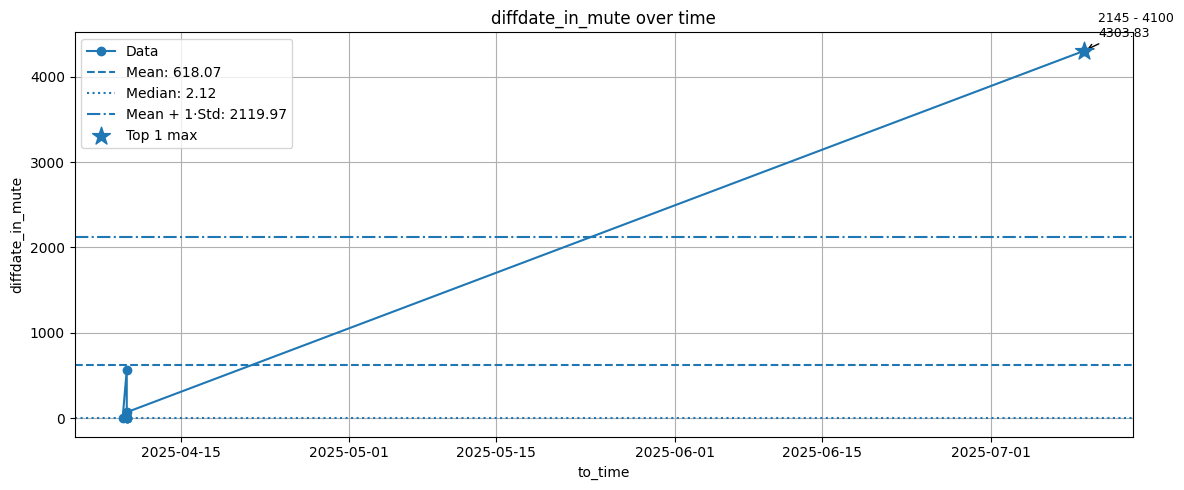

In [168]:
plot_scatter_with_rules(data,"to_time", "diffdate_in_mute","OperationtoOp",top_n=1,enable_above_threshold=False)

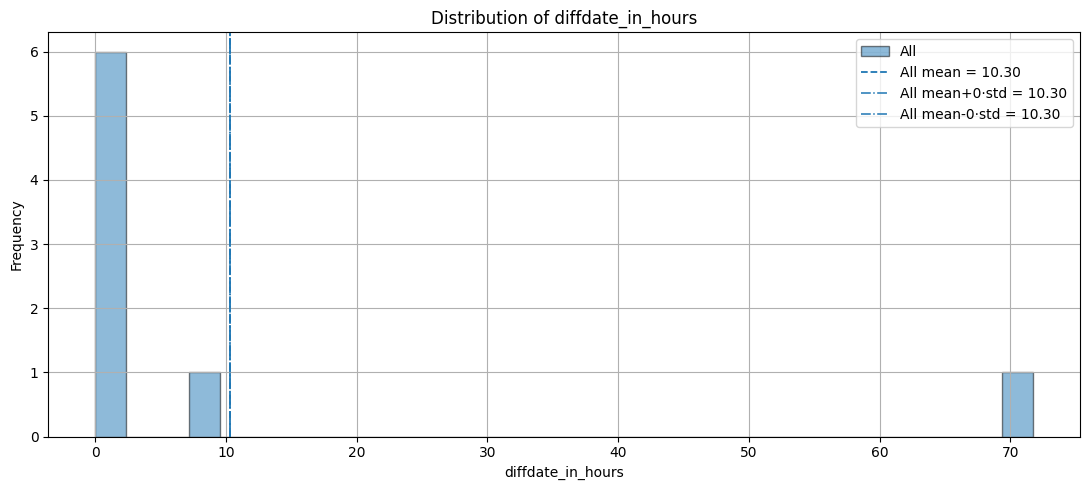

In [169]:
plot_distribution_with_hue(data,"diffdate_in_hours",enable_mean=True , std_k=0,enable_std=True)

In [170]:
import pandas as pd

def build_statistics_table(
    df: pd.DataFrame,
    value_col: str,
    hue_col: str = None,
    std_k: float = 1.0,
    round_digits: int = 3
) -> pd.DataFrame:
    """
    Build a statistics table for a numeric column,
    optionally grouped by a hue column.

    Parameters
    ----------
    df : pd.DataFrame
        Input data
    value_col : str
        Numeric column for statistics
    hue_col : str, optional
        Grouping column
    std_k : float
        Multiplier for std (mean ± k·std)
    round_digits : int
        Decimal rounding

    Returns
    -------
    pd.DataFrame
        Statistics table
    """

    cols = [value_col] + ([hue_col] if hue_col else [])
    data = df[cols].copy()
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna(subset=[value_col])

    if data.empty:
        raise ValueError("No valid numeric data.")

    def _stats(x: pd.Series):
        mean = x.mean()
        std = x.std(ddof=1)
        return pd.Series({
            "COUNT": len(x),
            "MEAN": round(mean, round_digits),
            "MEDIAN": round(x.median(), round_digits),
            "STD": round(std, round_digits),
            "MIN": round(x.min(), round_digits),
            "MAX": round(x.max(), round_digits),
            f"MEAN+{std_k}STD": round(mean + std_k * std, round_digits),
            f"MEAN-{std_k}STD": round(mean - std_k * std, round_digits),
        })

    if hue_col:
        stats_df = data.groupby(hue_col)[value_col].apply(_stats).reset_index()
    else:
        stats_df = _stats(data[value_col]).to_frame().T

    return stats_df


In [171]:
statsdata = build_statistics_table(data,"difdate_in_sec",std_k=3)

In [172]:
statsdata

,COUNT,MEAN,MEDIAN,STD,MIN,MAX,MEAN+3STD,MEAN-3STD
0,8.0,37084.125,127.0,90113.785,1.0,258230.0,307425.48,-233257.23


In [173]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_trend_with_period_avg_and_max(
    df: pd.DataFrame,
    time_col: str,
    value_col: str,
    label_col: str = None,

    bad_periods: list = None,   # [(start, end), ...]
    good_periods: list = None,  # [(start, end), ...]

    # display options
    show_markers: bool = True,
    shade_periods: bool = True,
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    show_grid: bool = True
):
    """
    Sequential trend plot (sorted by time) with:
    - Good/Bad shaded time windows
    - Mean line for Good period
    - Mean line for Bad period
    - Highlight Max in Good and Bad periods
    """

    # -------------------------
    # Prepare data
    # -------------------------
    cols = [time_col, value_col] + ([label_col] if label_col else [])
    data = df[cols].copy()

    data[time_col] = pd.to_datetime(data[time_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna(subset=[time_col, value_col]).sort_values(time_col)

    if data.empty:
        raise ValueError("No valid data to plot.")

    # -------------------------
    # Normalize periods
    # -------------------------
    def _normalize(periods):
        out = []
        if not periods:
            return out
        for s, e in periods:
            s = pd.to_datetime(s, errors="coerce")
            e = pd.to_datetime(e, errors="coerce")
            if pd.isna(s) or pd.isna(e):
                continue
            if e < s:
                s, e = e, s
            out.append((s, e))
        return out

    bad_p = _normalize(bad_periods)
    good_p = _normalize(good_periods)

    # -------------------------
    # Build masks
    # -------------------------
    def _in_period(ts, periods):
        m = pd.Series(False, index=ts.index)
        for s, e in periods:
            m |= (ts >= s) & (ts <= e)
        return m

    bad_mask = _in_period(data[time_col], bad_p)
    good_mask = _in_period(data[time_col], good_p)

    # Bad wins if overlap
    good_mask = good_mask & (~bad_mask)

    good_df = data.loc[good_mask]
    bad_df = data.loc[bad_mask]

    good_mean = good_df[value_col].mean() if not good_df.empty else None
    bad_mean = bad_df[value_col].mean() if not bad_df.empty else None

    max_good = good_df.nlargest(1, value_col) if not good_df.empty else None
    max_bad = bad_df.nlargest(1, value_col) if not bad_df.empty else None

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(12, 5))

    # Shaded periods
    if shade_periods:
        for s, e in good_p:
            plt.axvspan(s, e, alpha=0.15, label="Good period")
        for s, e in bad_p:
            plt.axvspan(s, e, alpha=0.25, label="Bad period")

    # Sequential trend line (the key improvement)
    marker = "o" if show_markers else None
    plt.plot(
        data[time_col],
        data[value_col],
        linestyle="-",
        linewidth=1.8,
        marker=marker,
        label=f"Trend ({len(data)})"
    )

    # Mean lines (separate)
    if good_mean is not None:
        plt.axhline(
            good_mean,
            linestyle="--",
            linewidth=2,
            label=f"Good mean = {good_mean:.2f}"
        )

    if bad_mean is not None:
        plt.axhline(
            bad_mean,
            linestyle=":",
            linewidth=2,
            label=f"Bad mean = {bad_mean:.2f}"
        )

    # Max highlights
    def _annotate_max(row, prefix):
        text = f"{prefix} MAX\n{row[value_col]:.2f}"
        if label_col:
            text = f"{prefix} MAX: {row[label_col]}\n{row[value_col]:.2f}"

        plt.scatter(
            row[time_col],
            row[value_col],
            s=240,
            marker="*",
            zorder=10,
            label=f"{prefix} MAX"
        )
        plt.annotate(
            text,
            xy=(row[time_col], row[value_col]),
            xytext=(10, 10),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->"),
            fontsize=9
        )

    if max_good is not None and not max_good.empty:
        _annotate_max(max_good.iloc[0], "GOOD")
    if max_bad is not None and not max_bad.empty:
        _annotate_max(max_bad.iloc[0], "BAD")

    # Labels
    plt.title(title or f"{value_col} with Good/Bad periods (sequential)")
    plt.xlabel(xlabel or time_col)
    plt.ylabel(ylabel or value_col)

    if show_grid:
        plt.grid(True)

    # Deduplicate legend labels
    handles, labels = plt.gca().get_legend_handles_labels()
    uniq_h, uniq_l, seen = [], [], set()
    for h, l in zip(handles, labels):
        if l not in seen:
            uniq_h.append(h)
            uniq_l.append(l)
            seen.add(l)
    plt.legend(uniq_h, uniq_l)

    plt.tight_layout()
    plt.show()


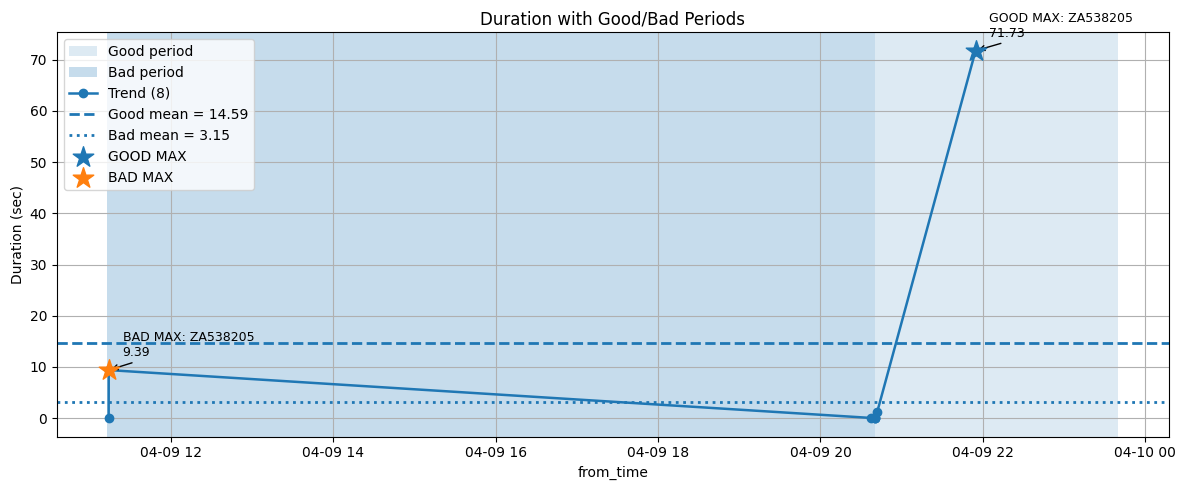

In [174]:


bad_periods = [
    ("2025-04-09 11:13", "2025-04-09 20:40"),

]

good_periods = [
    ("2025-04-09 20:40", "2025-04-09 23:40"),
]

plot_trend_with_period_avg_and_max(
    df=data,
    time_col="from_time",
    value_col="diffdate_in_hours",
    label_col="lotnumber",
    bad_periods=bad_periods,
    good_periods=good_periods,
    title="Duration with Good/Bad Periods",
    ylabel="Duration (sec)"
)

In [175]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

def plot_period_scatter_auto_order(
    df: pd.DataFrame,
    time_col: str,
    value_col: str,
    label_col: str = None,
    bad_period: tuple = None,   # (start, end)
    good_period: tuple = None,  # (start, end)
    title: str = "Duration with Good/Bad Periods",
    xlabel: str = None,
    ylabel: str = "Duration (sec)",
    show_grid: bool = True
):
    """
    2-panel scatter-only plot (light tone) with auto ordering:
    - The earlier period (by start time) will be on the LEFT.
    - Good is always blue, Bad is always red (regardless of order).
    """

    if bad_period is None or good_period is None:
        raise ValueError("Both bad_period and good_period must be provided.")

    # ---- prepare data
    cols = [time_col, value_col] + ([label_col] if label_col else [])
    data = df[cols].copy()
    data[time_col] = pd.to_datetime(data[time_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna(subset=[time_col, value_col]).sort_values(time_col)

    if data.empty:
        raise ValueError("No valid data to plot.")

    def _norm(p):
        s = pd.to_datetime(p[0], errors="coerce")
        e = pd.to_datetime(p[1], errors="coerce")
        if pd.isna(s) or pd.isna(e):
            raise ValueError("Period start/end must be valid datetime.")
        if e < s:
            s, e = e, s
        return s, e

    bad_s, bad_e = _norm(bad_period)
    good_s, good_e = _norm(good_period)

    # Slice
    bad_df = data[(data[time_col] >= bad_s) & (data[time_col] <= bad_e)]
    good_df = data[(data[time_col] >= good_s) & (data[time_col] <= good_e)]

    # Colors (light tone)
    BAD_BG, BAD_FG = "#f6c1c1", "#c0392b"    # light red, red
    GOOD_BG, GOOD_FG = "#cfe8f6", "#2471a3"  # light blue, blue

    # Build panel definitions and auto-sort by start time
    panels = [
        {"name": "Bad Period", "df": bad_df, "s": bad_s, "e": bad_e, "bg": BAD_BG, "fg": BAD_FG, "kind": "bad"},
        {"name": "Good Period", "df": good_df, "s": good_s, "e": good_e, "bg": GOOD_BG, "fg": GOOD_FG, "kind": "good"},
    ]
    panels.sort(key=lambda x: x["s"])  # earlier start goes left

    # ---- figure
    fig, (ax_left, ax_right) = plt.subplots(
        ncols=2, figsize=(15, 8), sharey=True,
        gridspec_kw={"wspace": 0.06}
    )
    fig.suptitle(title, fontsize=14)

    def _format_time_axis(ax):
        locator = mdates.AutoDateLocator(minticks=3, maxticks=6)
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)

    def _panel(ax, p, is_left_panel: bool):
        s, e = p["s"], p["e"]
        df_p, name, bg, fg = p["df"], p["name"], p["bg"], p["fg"]

        ax.axvspan(s, e, color=bg, alpha=0.22)

        # Scatter
        if not df_p.empty:
            ax.scatter(
                df_p[time_col],
                df_p[value_col],
                s=55,
                color=fg,
                alpha=0.90,
                edgecolor="white",
                linewidth=0.7
            )

            # Mean
            mean_val = df_p[value_col].mean()
            ax.hlines(mean_val, s, e, colors=fg, linestyles="--", linewidth=2)

            # Mean label slightly above mean line
            y0, y1 = ax.get_ylim()
            y_offset = (y1 - y0) * 0.02
            ax.text(
                s + (e - s) * 0.05,
                mean_val + y_offset,
                f"Mean = {mean_val:.2f}",
                color=fg,
                fontsize=12,
                va="bottom",
                ha="left"
            )

            # Max
            r = df_p.nlargest(1, value_col).iloc[0]
            ax.scatter(
                r[time_col], r[value_col],
                s=280, marker="*",
                color=fg, edgecolor="black",
                zorder=10
            )

            max_label = f"MAX = {r[value_col]:.2f}"
            if label_col:
                max_label = f"MAX: {r[label_col]}\n{r[value_col]:.2f}"

            # Annotate inward depending on which panel this is
            dx = 12 if is_left_panel else -90
            ha = "left" if is_left_panel else "right"
            ax.annotate(
                max_label,
                xy=(r[time_col], r[value_col]),
                xytext=(dx, 10),
                textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=fg),
                fontsize=9,
                ha=ha
            )

        # Header
        ax.text(
            0.5, 0.98, name,
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=14, fontweight="bold",
            bbox=dict(facecolor=bg, edgecolor="none", pad=6)
        )

        ax.set_xlim(s, e)
        if show_grid:
            ax.grid(True, alpha=0.35)

        _format_time_axis(ax)

    _panel(ax_left, panels[0], is_left_panel=True)
    _panel(ax_right, panels[1], is_left_panel=False)

    ax_left.set_ylabel(ylabel)
    ax_left.set_xlabel(xlabel or time_col)
    ax_right.set_xlabel(xlabel or time_col)

    plt.tight_layout()
    plt.show()


C:\Users\Aphiw\AppData\Local\Temp\ipykernel_19724\1405840709.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


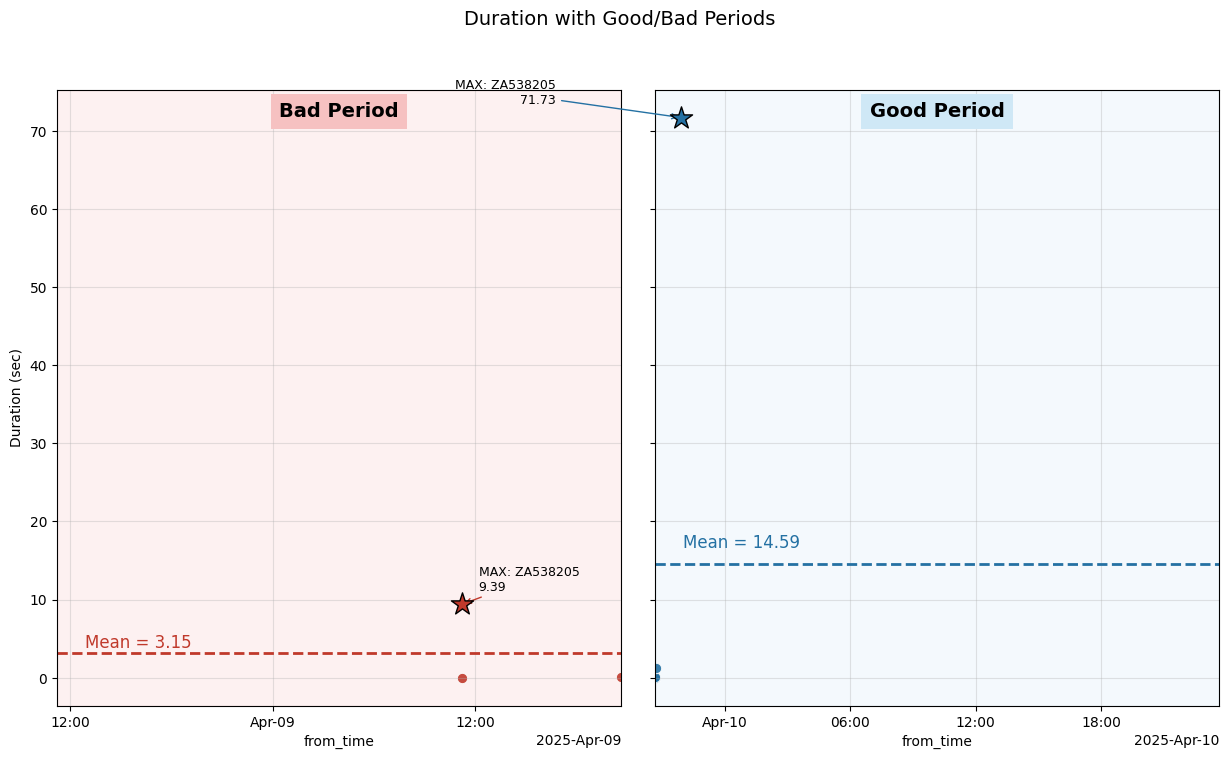

In [176]:
plot_period_scatter_auto_order(
    df=data,
    time_col="from_time",
    value_col="diffdate_in_hours",
    label_col="lotnumber",
    bad_period=("2025-04-08 11:13", "2025-04-09 20:40"),
    good_period=("2025-04-09 20:40", "2025-04-10 23:40"),
    title="Duration with Good/Bad Periods",
    ylabel="Duration (sec)"
)